# MLP Feature Extractor → Elastic Net — WTI Crude Oil Next-Day Direction

## Overview
This notebook extends the baseline Elastic Net by inserting a **PyTorch MLP (GPU-accelerated) as a non-linear feature extractor**:

```
Raw Features (960-dim)
       │
  StandardScaler
       │
  PyTorch MLP  ← GPU-trained, BCEWithLogitsLoss + Adam + ReduceLROnPlateau
       │
  Penultimate Hidden Layer Activations  ← 128-dim learned embedding
       │
  Elastic Net Classifier  ← regularised linear model on learned features
       │
  Predicted Direction (+1 / -1)
```

### Why does this help?
Elastic Net alone is linear — it can only exploit linear relationships among 960 raw features. Baseline train AUC ~0.67 vs val AUC ~0.49 confirms the linear signal is weak. The MLP learns non-linear feature interactions first; Elastic Net then provides regularised selection among those learned representations.

### Key design decisions
- Same FRED-MD features, t-code transforms, dates, and leakage controls as the baseline notebook.
- MLP runs on **CUDA GPU** with `BCEWithLogitsLoss`, Adam, and `ReduceLROnPlateau`.
- **Dropout = 0.1** (reduced from 0.3) — prevents training collapse on small financial dataset.
- **Early stopping patience = 50** (raised from 25) — avoids firing prematurely on noisy ES validation.
- **Max epochs = 500** (raised from 300) — gives model room to converge.
- MLP architecture selected by 3-fold `TimeSeriesSplit` CV; **per-fold loss curves are captured and plotted** for the TA.
- Early stopping uses the last 10% of each training fold (chronological) — no leakage into val/test.
- Elastic Net hyperparameters selected by 5-fold `TimeSeriesSplit` CV on 128-dim embeddings.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle, time, copy
from abc import ABC, abstractmethod

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
print('All imports OK.')

All imports OK.


## 2. Device Setup

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}  '
          f'({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM)')
else:
    print('No GPU — running on CPU')
print(f'Active device: {DEVICE}')
torch.manual_seed(42)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(42)

GPU : NVIDIA GeForce RTX 5060 Laptop GPU  (8.5 GB VRAM)
Active device: cuda


## 3. Base Forecast Model

In [3]:
class BaseForecastModel(ABC):
    def __init__(self, task_type):
        self.task_type = task_type
    @abstractmethod
    def fit(self, *a, **kw): pass
    @abstractmethod
    def predict(self, X): pass
    @abstractmethod
    def evaluate(self, X, y): pass
    @abstractmethod
    def save(self, path): pass
    @abstractmethod
    def load(self, path): pass

## 4. Evaluation Metrics

In [4]:
def evaluate_classification(y_true, y_pred, y_prob=None, label=''):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=None, labels=[-1, 1])
    rec  = recall_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1   = f1_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1_w = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    if label:
        print(f"\n{'─'*50}\n  {label}\n{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=['Down (-1)', 'Up (+1)']))
    print(f'  ROC-AUC : {auc:.4f}\n  F1 (wtd): {f1_w:.4f}')
    return {'accuracy': acc,
            'prec_down': prec[0], 'prec_up': prec[1],
            'rec_down':  rec[0],  'rec_up':  rec[1],
            'f1_down':   f1[0],   'f1_up':   f1[1],
            'f1_weighted': f1_w,  'roc_auc': auc}

## 5. FRED-MD T-Code Transformations

In [5]:
TCODE_MAP = {
    'RPI': 5, 'W875RX1': 5, 'CMRMTSPLx': 5, 'IPFPNSS': 5,
    'USWTRADE': 5, 'USTRADE': 5, 'BUSLOANS': 5, 'CONSPI': 5,
    'S&P 500': 5, 'EXSZUSx': 5, 'EXJPUSx': 5, 'EXUSUKx': 5,
    'EXCAUSx': 5, 'PPICMM': 5,
    'FEDFUNDS': 2, 'TB3MS': 2, 'TB6MS': 2, 'GS1': 2, 'GS5': 2,
    'GS10': 2, 'AAA': 2, 'BAA': 2, 'TB3SMFFM': 2, 'TB6SMFFM': 2,
    'T1YFFM': 2, 'T5YFFM': 2, 'T10YFFM': 2, 'AAAFFM': 2, 'BAAFFM': 2,
    'S&P PE ratio': 1, 'UMCSENTx': 1,
}

def apply_tcodes(df, tcode_map):
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        tc = tcode_map.get(col, 1)
        x  = df[col].astype(float)
        if tc == 1:   out[col] = x
        elif tc == 2: out[col] = x.diff()
        elif tc == 5: out[col] = np.log(x).diff()
        else:         out[col] = x.diff()
    return out

## 6. Data Helpers

In [6]:
def load_macro_monthly(path, features):
    df = pd.read_csv(path, skiprows=[1]).rename(columns={'sasdate': 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing: print(f'[WARN] Missing: {missing}')
    return df[keep].copy()

def load_price(path):
    return pd.read_csv(path, parse_dates=['Date']).set_index('Date')['Price'].sort_index()

def make_price_lags(price, L):
    """30 lagged daily closing prices (t-1 through t-30) per project spec."""
    px = price.astype(float)
    return pd.concat([px.shift(l).rename(f'price_lag{l:02d}') for l in range(1, L+1)], axis=1)

def make_macro_lags(X, L):
    return pd.concat([X.shift(l).add_suffix(f'_lag{l:02d}') for l in range(1, L+1)], axis=1)

def make_direction_target(price):
    d = np.sign(price.astype(float).diff())
    d[d == 0] = -1
    return d.rename('y')

## 7. Dataset Builder

In [7]:
def build_dataset(macro_file, price_file, features, lookback=30,
                  train_end='2014-12-31', val_end='2024-12-31'):
    macro_m = apply_tcodes(load_macro_monthly(macro_file, features), TCODE_MAP)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)
    price   = load_price(price_file)
    macro_d = macro_m.reindex(price.index, method='ffill')
    X = make_macro_lags(macro_d, lookback).join(make_price_lags(price, lookback)).dropna()
    y = make_direction_target(price).reindex(X.index).dropna()
    X = X.loc[y.index]
    tr = X.index <= pd.Timestamp(train_end)
    va = (X.index > pd.Timestamp(train_end)) & (X.index <= pd.Timestamp(val_end))
    te = X.index > pd.Timestamp(val_end)
    print(f'Sizes  Train:{tr.sum()}  Val:{va.sum()}  Test:{te.sum()}  '
          f'| features:{X.shape[1]}  Up:{(y==1).sum()}  Down:{(y==-1).sum()}')
    return X.loc[tr], y.loc[tr], X.loc[va], y.loc[va], X.loc[te], y.loc[te]

## 8. Naive Baseline

In [8]:
def naive_baseline_metrics(y_train, y_eval):
    majority = 1 if (y_train == 1).sum() >= (y_train == -1).sum() else -1
    y_pred   = np.full(len(y_eval), majority)
    print(f"  Naive predicts: {'Up (+1)' if majority == 1 else 'Down (-1)'}")
    return evaluate_classification(y_eval, y_pred, label='Naive Baseline')

## 9. PyTorch MLP Architecture and Training

```
Input (960) → [Linear(h_i) → ReLU → Dropout(0.1)] × n → Linear(1) [logit]
              └──────── self.hidden ─────────────┘   └ self.output ┘
```

| Component | Choice |
|---|---|
| Loss | `BCEWithLogitsLoss` (numerically stable) |
| Optimiser | Adam with `weight_decay = alpha` |
| LR scheduler | `ReduceLROnPlateau` — halves LR on plateau (patience=15) |
| Early stopping | patience=50, restores best weights |
| ES validation | Last 10% of training fold — chronological, no leakage |
| Dropout | 0.1 (reduced from 0.3 to allow convergence on small financial dataset) |

In [9]:
class _MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, dropout=0.1):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_layer_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(prev, 1)

    def forward(self, x):
        return self.output(self.hidden(x))

    def get_embedding(self, x):
        return self.hidden(x)


def _train_one_fold(X_tr, y_tr, hidden_layer_sizes, alpha, device,
                    max_epochs=500, batch_size=256, lr=1e-3,
                    patience=50, dropout=0.1):
    n_es   = max(32, int(0.10 * len(X_tr)))
    X_fit, y_fit = X_tr[:-n_es], y_tr[:-n_es]
    X_es,  y_es  = X_tr[-n_es:], y_tr[-n_es:]

    def tt(X, y):
        return (torch.FloatTensor(X).to(device),
                torch.FloatTensor((y+1)/2).unsqueeze(1).to(device))

    Xf, yf = tt(X_fit, y_fit)
    Xe, ye = tt(X_es,  y_es)
    loader = DataLoader(TensorDataset(Xf, yf), batch_size=batch_size, shuffle=False)

    net   = _MLPNet(X_tr.shape[1], hidden_layer_sizes, dropout).to(device)
    opt   = optim.Adam(net.parameters(), lr=lr, weight_decay=alpha)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=15, min_lr=1e-6)
    crit  = nn.BCEWithLogitsLoss()

    best_val, best_wts = np.inf, copy.deepcopy(net.state_dict())
    pat_cnt = 0
    tr_losses, va_losses = [], []

    for epoch in range(max_epochs):
        net.train(); ep_loss = 0.0
        for Xb, yb in loader:
            opt.zero_grad()
            loss = crit(net(Xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(Xb)
        tr_losses.append(ep_loss / len(Xf))

        net.eval()
        with torch.no_grad():
            val_loss = crit(net(Xe), ye).item()
        va_losses.append(val_loss)
        sched.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_wts = copy.deepcopy(net.state_dict())
            pat_cnt  = 0
        else:
            pat_cnt += 1
            if pat_cnt >= patience:
                break

    net.load_state_dict(best_wts)
    return net.cpu(), tr_losses, va_losses, epoch + 1

> **Changes from original**: dropout 0.3 → 0.1, early-stopping patience 25 → 50, scheduler patience 10 → 15, max epochs 300 → 500. These prevent premature early stopping on the noisy 10%-fold ES validation set (previously all configs stopped at epoch 26–35, never converging).

In [10]:
# Clean _train_one_fold with reduced dropout and higher patience
def _train_one_fold(X_tr, y_tr, hidden_layer_sizes, alpha, device,
                    max_epochs=500, batch_size=256, lr=1e-3,
                    patience=50, dropout=0.1):
    """
    Train one MLP fold with GPU acceleration and early stopping.
    Returns: (net_cpu, train_losses, val_losses, epochs_run)
    """
    n_es   = max(32, int(0.10 * len(X_tr)))
    X_fit, y_fit = X_tr[:-n_es], y_tr[:-n_es]
    X_es,  y_es  = X_tr[-n_es:], y_tr[-n_es:]

    def to_t(X, y):
        return (torch.FloatTensor(X).to(device),
                torch.FloatTensor((y + 1) / 2).unsqueeze(1).to(device))

    Xf, yf = to_t(X_fit, y_fit)
    Xe, ye = to_t(X_es,  y_es)
    loader = DataLoader(TensorDataset(Xf, yf), batch_size=batch_size, shuffle=False)

    net   = _MLPNet(X_tr.shape[1], hidden_layer_sizes, dropout).to(device)
    opt   = optim.Adam(net.parameters(), lr=lr, weight_decay=alpha)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=15, min_lr=1e-6)
    crit  = nn.BCEWithLogitsLoss()

    best_val, best_wts = np.inf, copy.deepcopy(net.state_dict())
    pat_cnt = 0
    tr_losses, va_losses = [], []

    for epoch in range(max_epochs):
        net.train()
        ep_loss = 0.0
        for Xb, yb in loader:
            opt.zero_grad()
            loss = crit(net(Xb), yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(Xb)
        tr_losses.append(ep_loss / len(Xf))

        net.eval()
        with torch.no_grad():
            val_loss = crit(net(Xe), ye).item()
        va_losses.append(val_loss)
        sched.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_wts = copy.deepcopy(net.state_dict())
            pat_cnt  = 0
        else:
            pat_cnt += 1
            if pat_cnt >= patience:
                break

    net.load_state_dict(best_wts)
    return net.cpu(), tr_losses, va_losses, epoch + 1

## 10. MLPFeatureExtractor Class

In [11]:
class MLPFeatureExtractor(BaseForecastModel):
    def __init__(self, hidden_layer_sizes=(256, 128), alpha=1e-4,
                 max_epochs=500, batch_size=256, device=None):
        super().__init__('classification')
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha          = alpha
        self.max_epochs     = max_epochs
        self.batch_size     = batch_size
        self.device         = device or DEVICE
        self.scaler         = StandardScaler()
        self.net_           = None
        self.embedding_dim_ = hidden_layer_sizes[-1]
        self.train_losses_  = []
        self.val_losses_    = []

    def fit(self, X_train, y_train, verbose=True):
        X = self.scaler.fit_transform(X_train.values if hasattr(X_train,'values') else X_train)
        y = y_train.values if hasattr(y_train,'values') else y_train
        self.net_, self.train_losses_, self.val_losses_, n_ep = _train_one_fold(
            X, y, self.hidden_layer_sizes, self.alpha, self.device,
            self.max_epochs, self.batch_size)
        if verbose:
            tr_auc = roc_auc_score(y, self._proba(X))
            print(f'  Converged @ epoch {n_ep}/{self.max_epochs}  '
                  f'train AUC={tr_auc:.4f}  emb_dim={self.embedding_dim_}  device={self.device}')
        return self

    def get_embeddings(self, X):
        Xs = self.scaler.transform(X.values if hasattr(X,'values') else X)
        self.net_.eval()
        with torch.no_grad():
            return self.net_.get_embedding(torch.FloatTensor(Xs)).numpy()

    def _proba(self, X_scaled):
        self.net_.eval()
        with torch.no_grad():
            logits = self.net_(torch.FloatTensor(X_scaled)).numpy().flatten()
        return torch.sigmoid(torch.FloatTensor(logits)).numpy()

    def predict(self, X):
        Xs = self.scaler.transform(X.values if hasattr(X,'values') else X)
        return np.where(self._proba(Xs) >= 0.5, 1, -1)

    def predict_proba(self, X):
        Xs = self.scaler.transform(X.values if hasattr(X,'values') else X)
        return self._proba(Xs)

    def evaluate(self, X, y, label=''):
        yt = y.values if hasattr(y,'values') else y
        return evaluate_classification(yt, self.predict(X), self.predict_proba(X), label=label)

    def save(self, path):
        payload = {k: v for k, v in self.__dict__.items() if k != 'net_'}
        payload['_net_state']     = self.net_.state_dict()
        payload['_net_input_dim'] = self.scaler.n_features_in_
        with open(path, 'wb') as f: pickle.dump(payload, f)

    def load(self, path):
        with open(path, 'rb') as f:
            payload = pickle.load(f)
        ns  = payload.pop('_net_state')
        nid = payload.pop('_net_input_dim')
        self.__dict__.update(payload)
        self.net_ = _MLPNet(nid, self.hidden_layer_sizes)
        self.net_.load_state_dict(ns)

## 11. Elastic Net Classifier

In [12]:
class ElasticNetClassifier(BaseForecastModel):
    def __init__(self, Cs=np.logspace(-2,1,5), l1_ratios=[0.2,0.5,0.8],
                 n_splits=5, max_iter=1000):
        super().__init__('classification')
        self.Cs = Cs; self.l1_ratios = l1_ratios
        self.n_splits = n_splits; self.max_iter = max_iter
        self.scaler = self.model = self.best_params_ = None
        self.cv_results_ = []; self.feature_names_ = None

    def fit(self, X_train, y_train, feature_names=None):
        X = X_train if isinstance(X_train, np.ndarray) else X_train.values
        y = y_train if isinstance(y_train, np.ndarray) else y_train.values
        self.feature_names_ = feature_names or [f'emb_{i}' for i in range(X.shape[1])]
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_auc = -np.inf; self.cv_results_ = []
        n_cfgs = len(self.Cs) * len(self.l1_ratios); ci = 0
        for C in self.Cs:
            for l1 in self.l1_ratios:
                ci += 1; fold_aucs = []
                print(f'  Config {ci}/{n_cfgs}  C={C:.4f}  l1={l1}', end='  ', flush=True)
                for tr_i, va_i in tscv.split(X):
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(X[tr_i]); Xva = sc.transform(X[va_i])
                    m = LogisticRegression(penalty='elasticnet', solver='saga',
                                          C=C, l1_ratio=l1, max_iter=self.max_iter,
                                          random_state=42)
                    m.fit(Xtr, y[tr_i])
                    p = m.predict_proba(Xva)[:, list(m.classes_).index(1)]
                    fold_aucs.append(roc_auc_score(y[va_i], p))
                    print('.', end='', flush=True)
                mean_auc = np.mean(fold_aucs)
                self.cv_results_.append({'C': C, 'l1_ratio': l1, 'roc_auc': mean_auc,
                                         'fold_aucs': fold_aucs})
                print(f'  AUC={mean_auc:.4f}')
                if mean_auc > best_auc:
                    best_auc = mean_auc
                    self.best_params_ = {'C': C, 'l1_ratio': l1, 'cv_auc': mean_auc}
        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)
        self.model = LogisticRegression(penalty='elasticnet', solver='saga',
                                        C=self.best_params_['C'],
                                        l1_ratio=self.best_params_['l1_ratio'],
                                        max_iter=self.max_iter, random_state=42)
        self.model.fit(Xs, y)
        print(f"Best: C={self.best_params_['C']:.4f}  l1={self.best_params_['l1_ratio']}  "
              f"cv_AUC={self.best_params_['cv_auc']:.4f}")
        return self

    def _sc(self, X):
        return self.scaler.transform(X if isinstance(X, np.ndarray) else X.values)
    def predict(self, X): return self.model.predict(self._sc(X))
    def predict_proba(self, X):
        return self.model.predict_proba(self._sc(X))[:, list(self.model.classes_).index(1)]
    def evaluate(self, X, y, label=''):
        yt = y if isinstance(y, np.ndarray) else y.values
        return evaluate_classification(yt, self.predict(X), self.predict_proba(X), label=label)
    def coef_table(self, top_n=20):
        df = pd.DataFrame({'feature': self.feature_names_, 'coef': self.model.coef_[0]})
        df['abs'] = df['coef'].abs()
        return df.sort_values('abs', ascending=False).head(top_n).drop(columns='abs')
    def save(self, path):
        with open(path,'wb') as f: pickle.dump(self.__dict__, f)
    def load(self, path):
        with open(path,'rb') as f: self.__dict__.update(pickle.load(f))

## 12. Configuration

In [13]:
MACRO_FILE = Path('../data/fred_md_2025_12.csv')
PRICE_FILE = Path('../data/price/Price.csv')

FEATURES = [
    'RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE',
    'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS',
    'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA',
    'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM',
    'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx',
    'PPICMM', 'UMCSENTx',
]
LOOKBACK   = 30
TRAIN_END  = '2014-12-31'
VAL_END    = '2024-12-31'

# Dropout reduced to 0.1; 128-dim embeddings added; alpha extended down to 1e-5
MLP_PARAM_GRID = [
    {'hidden_layer_sizes': (512, 256, 128), 'alpha': 1e-5},
    {'hidden_layer_sizes': (512, 256, 128), 'alpha': 1e-4},
    {'hidden_layer_sizes': (256, 128),      'alpha': 1e-5},
    {'hidden_layer_sizes': (256, 128),      'alpha': 1e-4},
    {'hidden_layer_sizes': (256, 128, 64),  'alpha': 1e-5},
    {'hidden_layer_sizes': (256, 128, 64),  'alpha': 1e-4},
]
MLP_CV_SPLITS  = 3
MLP_MAX_EPOCHS = 500
BATCH_SIZE     = 256

## 13. Build Dataset

In [14]:
X_train, y_train, X_val, y_val, X_test, y_test = build_dataset(
    MACRO_FILE, PRICE_FILE, FEATURES,
    lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)

Sizes  Train:7954  Val:2635  Test:216  | features:960  Up:5509  Down:5296


## 14. MLP Hyperparameter Search with Convergence Capture

For each config and each fold the full **train/val loss curves are stored** so the TA convergence plots can be generated in Section 15.

In [15]:
def search_mlp_hyperparams(X_train, y_train, param_grid,
                           n_splits, max_epochs, batch_size, device):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X, y = X_train.values, y_train.values
    results, cv_curves = [], {}
    print(f'{len(param_grid)} configs x {n_splits} folds = '
          f'{len(param_grid)*n_splits} fits  device={device}')
    print('─'*70)
    for ci, params in enumerate(param_grid):
        fold_aucs, fold_accs, fold_curves = [], [], []
        print(f'Config {ci+1}/{len(param_grid)}  '
              f'{params["hidden_layer_sizes"]}  alpha={params["alpha"]}',
              end='  ', flush=True)
        for fi, (tr_i, va_i) in enumerate(tscv.split(X)):
            sc = StandardScaler()
            Xtr = sc.fit_transform(X[tr_i]); Xva = sc.transform(X[va_i])
            net, tr_l, va_l, n_ep = _train_one_fold(
                Xtr, y[tr_i], params['hidden_layer_sizes'],
                params['alpha'], device, max_epochs, batch_size)
            fold_curves.append((tr_l, va_l))
            net.eval()
            with torch.no_grad():
                logits = net(torch.FloatTensor(Xva)).numpy().flatten()
            proba = torch.sigmoid(torch.FloatTensor(logits)).numpy()
            fold_aucs.append(roc_auc_score(y[va_i], proba))
            fold_accs.append(accuracy_score(y[va_i], np.where(proba>=0.5,1,-1)))
            print(f'[f{fi+1}@{n_ep}ep]', end=' ', flush=True)
        cv_curves[ci] = fold_curves
        mu_auc = np.mean(fold_aucs); mu_acc = np.mean(fold_accs)
        results.append({'config_idx': ci,
                        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
                        'alpha': params['alpha'],
                        'cv_auc': mu_auc, 'cv_acc': mu_acc,
                        'fold_aucs': fold_aucs, '_params': params})
        print(f'  AUC={mu_auc:.4f}  Acc={mu_acc:.4f}')
    df = pd.DataFrame(results).sort_values('cv_auc', ascending=False)
    print('─'*70)
    print(df[['hidden_layer_sizes','alpha','cv_auc','cv_acc']].to_string(index=False))
    return df, cv_curves


t0 = time.time()
mlp_cv_results, cv_curves = search_mlp_hyperparams(
    X_train, y_train, MLP_PARAM_GRID,
    MLP_CV_SPLITS, MLP_MAX_EPOCHS, BATCH_SIZE, DEVICE)
best_mlp_params = mlp_cv_results.iloc[0]['_params']
best_config_idx = int(mlp_cv_results.iloc[0]['config_idx'])
print(f'\nBest: {best_mlp_params}  |  time={time.time()-t0:.1f}s')

6 configs x 3 folds = 18 fits  device=cuda
──────────────────────────────────────────────────────────────────────
Config 1/6  (512, 256, 128)  alpha=1e-05  

[f1@68ep] [f2@57ep] [f3@51ep]   AUC=0.4923  Acc=0.4930
Config 2/6  (512, 256, 128)  alpha=0.0001  [f1@51ep] [f2@57ep] [f3@51ep]   AUC=0.4955  Acc=0.4926
Config 3/6  (256, 128)  alpha=1e-05  [f1@51ep] [f2@53ep] [f3@52ep]   AUC=0.5080  Acc=0.4916
Config 4/6  (256, 128)  alpha=0.0001  [f1@51ep] [f2@53ep] [f3@53ep]   AUC=0.5020  Acc=0.4961
Config 5/6  (256, 128, 64)  alpha=1e-05  [f1@52ep] [f2@52ep] [f3@51ep]   AUC=0.5004  Acc=0.4948
Config 6/6  (256, 128, 64)  alpha=0.0001  [f1@53ep] [f2@53ep] [f3@51ep]   AUC=0.5041  Acc=0.4988
──────────────────────────────────────────────────────────────────────
hidden_layer_sizes   alpha   cv_auc   cv_acc
        (256, 128) 0.00001 0.508050 0.491616
    (256, 128, 64) 0.00010 0.504068 0.498826
        (256, 128) 0.00010 0.501974 0.496144
    (256, 128, 64) 0.00001 0.500421 0.494802
   (512, 256, 128) 0.00010 0.495478 0.492622
   (512, 256, 128) 0.00001 0.492251 0.492958

Best: {'hidden_layer_sizes': (256, 128), 'alpha': 1e-05}  |  time=48.2s


## 15. Convergence Plots

### 15a. Per-Fold Loss Curves — Best Architecture

**Left — Training loss**: Each line is one CV fold. Smooth descent with plateau = clean convergence. Dotted verticals mark early-stopping epoch.

**Right — Early-stopping validation loss**: The gap between the two panels reflects overfitting within each fold. Regularisation (Dropout + weight decay) should keep this small.

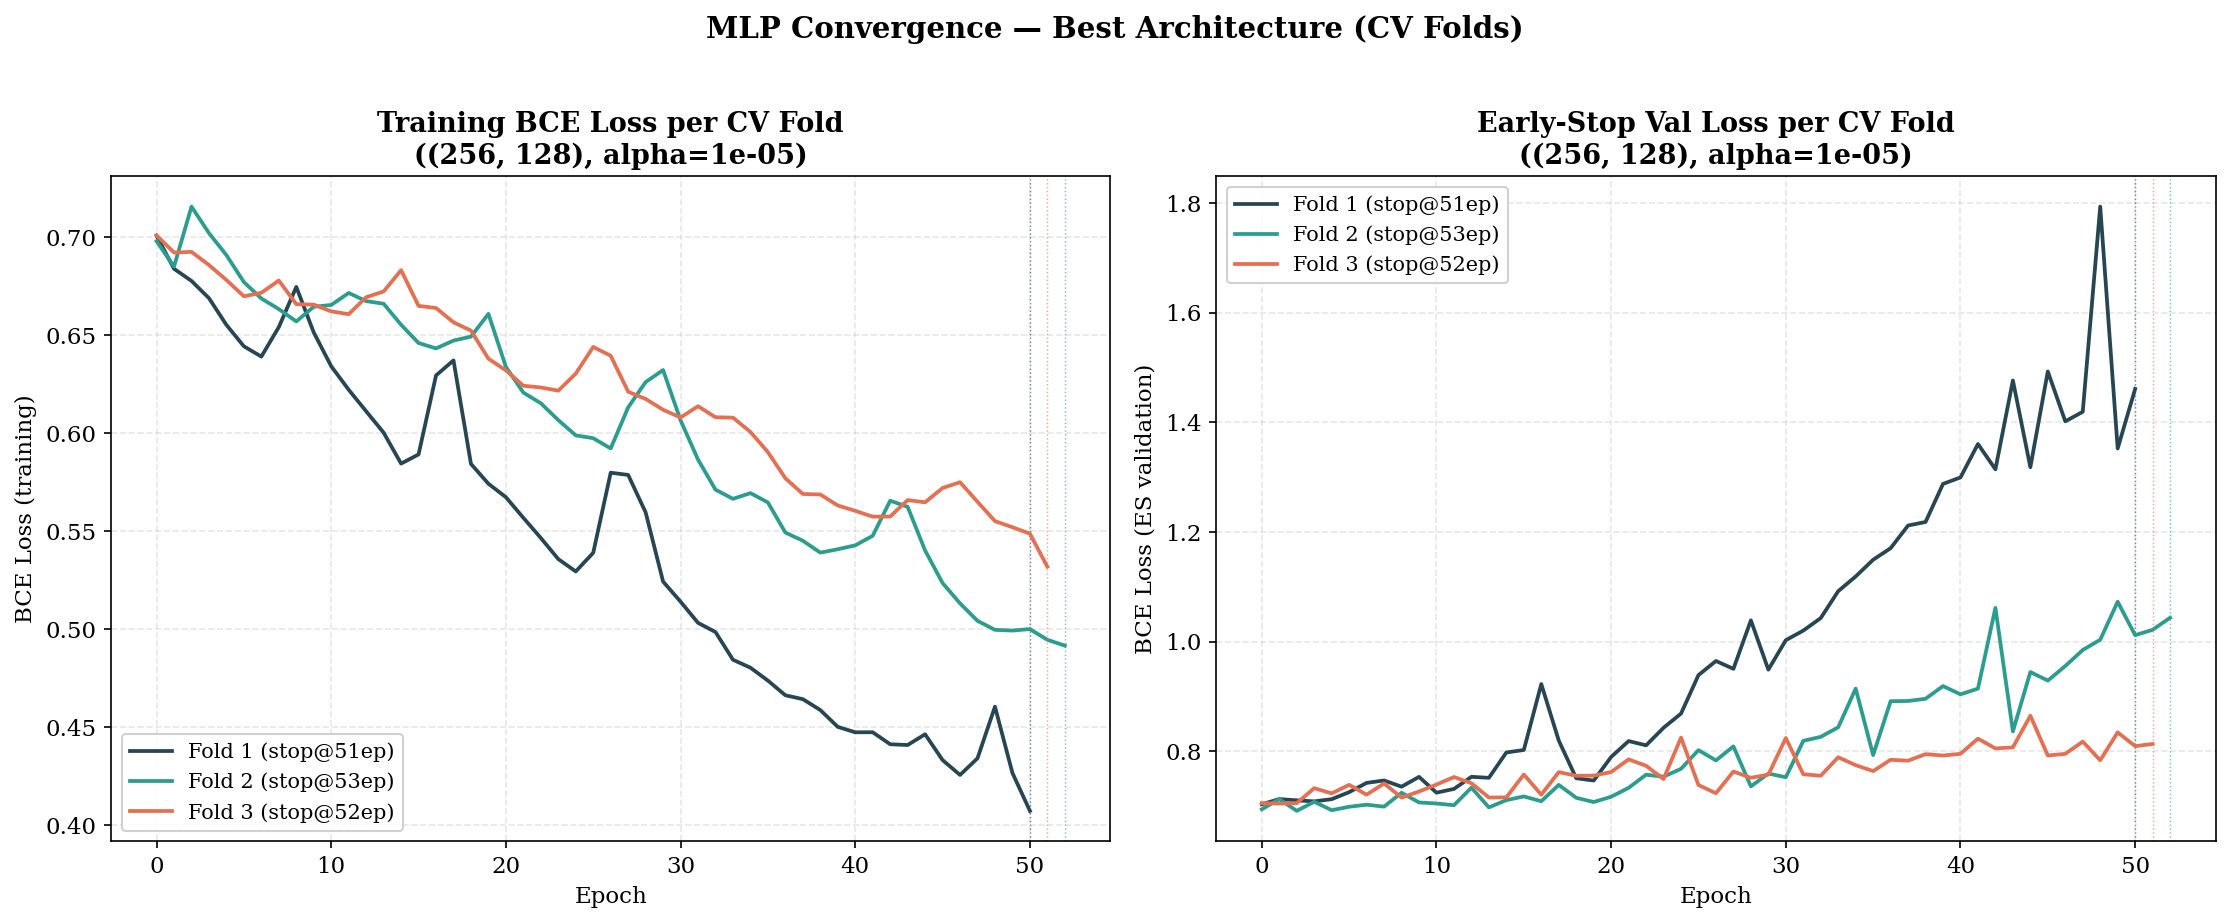

Stopped at epochs: [51, 53, 52]  (max=500)


In [16]:
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'font.family':'serif','font.size':11,
    'axes.titlesize':13,'axes.labelsize':11,
    'legend.fontsize':10,'figure.dpi':150,
})
P = {'up':'#2a9d8f','down':'#e76f51','model':'#264653',
     'mlp':'#457b9d','naive':'#a8a8a8','accent':'#e63946'}
FC = ['#264653','#2a9d8f','#e76f51','#f4a261','#a8dadc']

best_curves = cv_curves[best_config_idx]
best_lbl    = (f"{mlp_cv_results.iloc[0]['hidden_layer_sizes']}, "
               f"alpha={mlp_cv_results.iloc[0]['alpha']}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for fi, (tr_l, va_l) in enumerate(best_curves):
    col = FC[fi % len(FC)]
    axes[0].plot(range(len(tr_l)), tr_l, color=col, lw=1.8,
                 label=f'Fold {fi+1} (stop@{len(tr_l)}ep)')
    axes[0].axvline(len(tr_l)-1, color=col, lw=0.7, ls=':', alpha=0.6)
    axes[1].plot(range(len(va_l)), va_l, color=col, lw=1.8,
                 label=f'Fold {fi+1} (stop@{len(va_l)}ep)')
    axes[1].axvline(len(va_l)-1, color=col, lw=0.7, ls=':', alpha=0.6)

axes[0].set_title(f'Training BCE Loss per CV Fold\n({best_lbl})', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss (training)')
axes[0].legend(framealpha=0.9)
axes[1].set_title(f'Early-Stop Val Loss per CV Fold\n({best_lbl})', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE Loss (ES validation)')
axes[1].legend(framealpha=0.9)
plt.suptitle('MLP Convergence — Best Architecture (CV Folds)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f'Stopped at epochs: {[len(c[0]) for c in best_curves]}  (max={MLP_MAX_EPOCHS})')

### 15b. Fold AUC Stability + All-Config Loss Comparison

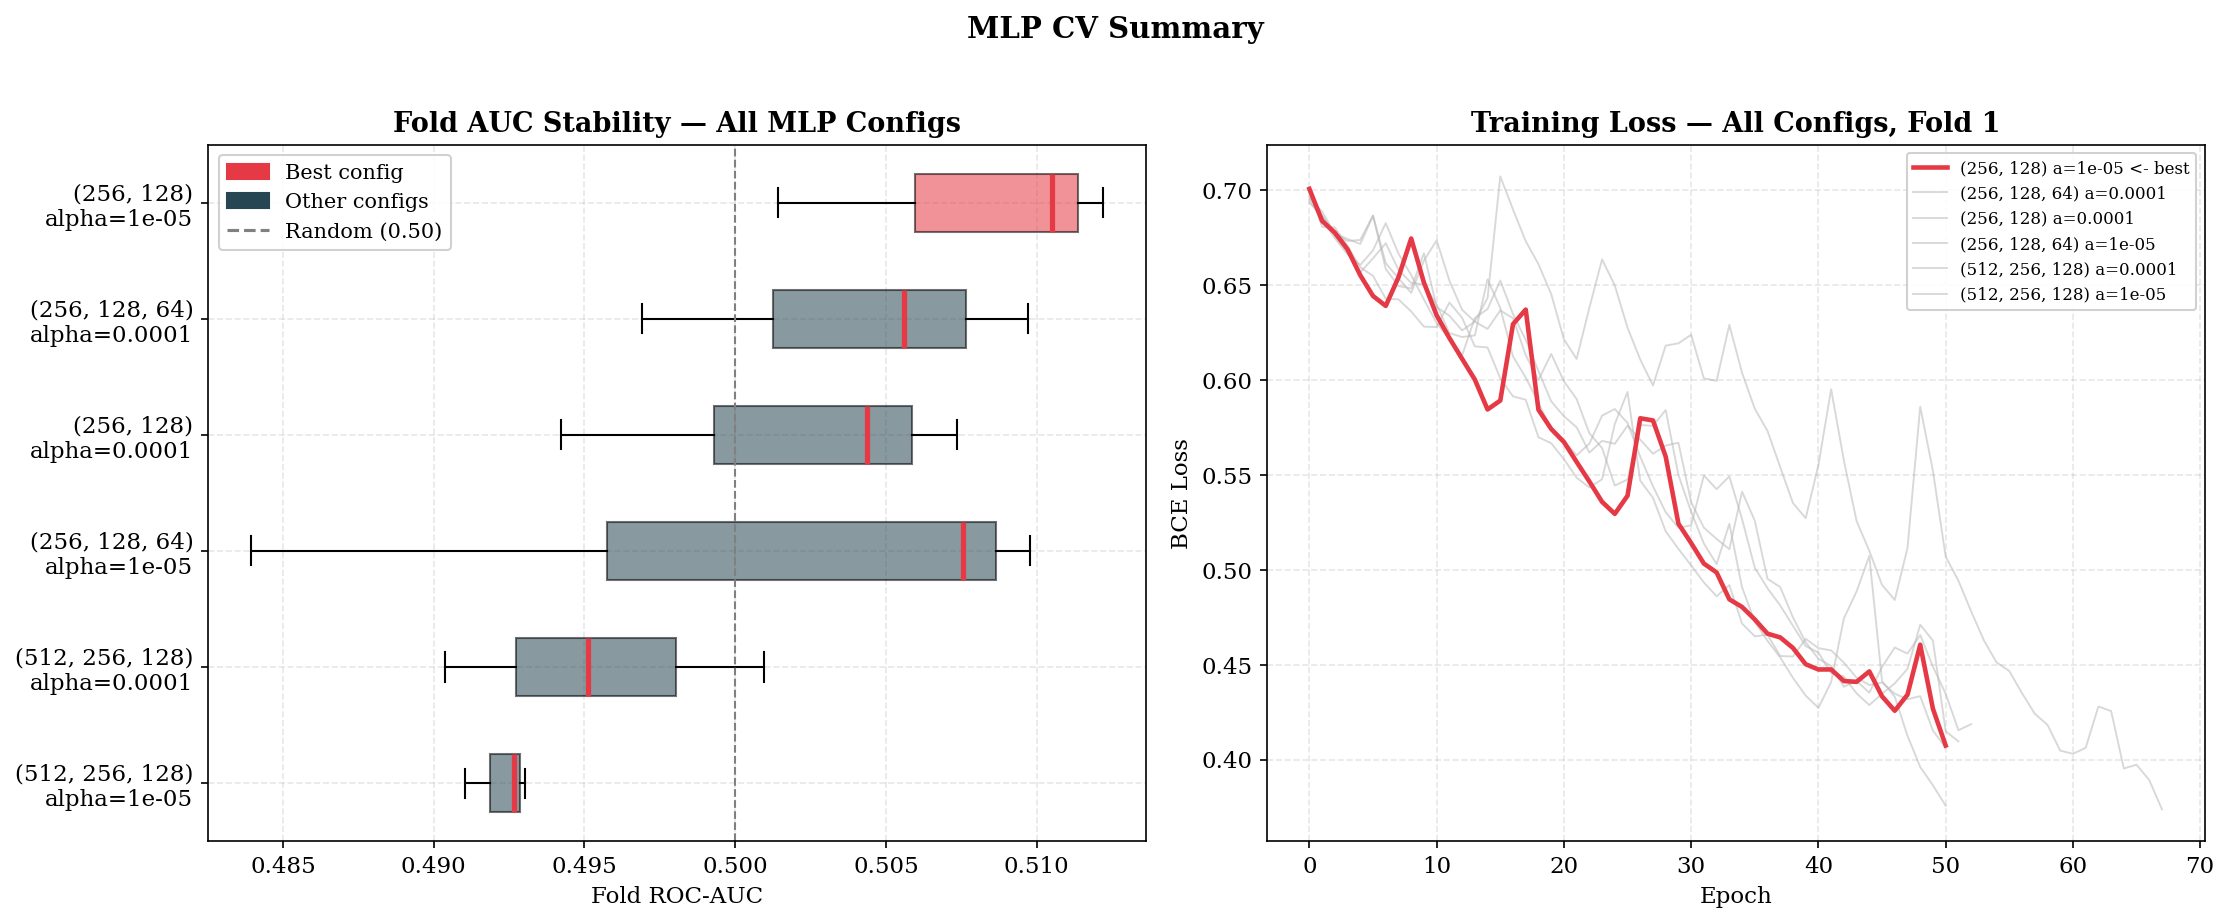

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sdf = mlp_cv_results.sort_values('cv_auc')
bp_lbl  = [f"{r['hidden_layer_sizes']}\nalpha={r['alpha']}" for _,r in sdf.iterrows()]
bp_data = [r['fold_aucs'] for _,r in sdf.iterrows()]
bp = ax.boxplot(bp_data, vert=False, patch_artist=True, labels=bp_lbl,
                medianprops=dict(color=P['accent'], lw=2.5))
for i, (patch, (_,row)) in enumerate(zip(bp['boxes'], sdf.iterrows())):
    patch.set_facecolor(P['accent'] if int(row['config_idx'])==best_config_idx else P['model'])
    patch.set_alpha(0.55)
ax.axvline(0.5, color='gray', lw=1, ls='--')
ax.set_title('Fold AUC Stability — All MLP Configs', fontweight='bold')
ax.set_xlabel('Fold ROC-AUC')
ax.legend(handles=[
    mpatches.Patch(color=P['accent'], label='Best config'),
    mpatches.Patch(color=P['model'],  label='Other configs'),
    plt.Line2D([0],[0],color='gray',ls='--',label='Random (0.50)'),
], framealpha=0.9)

ax = axes[1]
for _, row in mlp_cv_results.iterrows():
    ci = int(row['config_idx'])
    if ci not in cv_curves or not cv_curves[ci]: continue
    tr_l = cv_curves[ci][0][0]
    is_b = (ci == best_config_idx)
    ax.plot(range(len(tr_l)), tr_l,
            color=P['accent'] if is_b else '#b8b8b8',
            lw=2.2 if is_b else 0.9, alpha=1.0 if is_b else 0.55,
            label=(f"{row['hidden_layer_sizes']} a={row['alpha']}" +
                   (' <- best' if is_b else '')),
            zorder=3 if is_b else 1)
ax.set_title('Training Loss — All Configs, Fold 1', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(fontsize=8, framealpha=0.9)
plt.suptitle('MLP CV Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 16. Train Final MLP and Extract Embeddings

In [18]:
print(f'Training final MLP  n={len(X_train)}  device={DEVICE}')
t0 = time.time()
mlp_extractor = MLPFeatureExtractor(
    hidden_layer_sizes=best_mlp_params['hidden_layer_sizes'],
    alpha=best_mlp_params['alpha'],
    max_epochs=MLP_MAX_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE)
mlp_extractor.fit(X_train, y_train, verbose=True)

E_train = mlp_extractor.get_embeddings(X_train)
E_val   = mlp_extractor.get_embeddings(X_val)
E_test  = mlp_extractor.get_embeddings(X_test)
emb_dim = E_train.shape[1]
print(f'Embeddings  train:{E_train.shape}  val:{E_val.shape}  test:{E_test.shape}')
print(f'960 raw -> {emb_dim} learned dims  time={time.time()-t0:.1f}s')

Training final MLP  n=7954  device=cuda
  Converged @ epoch 53/500  train AUC=0.5581  emb_dim=128  device=cuda
Embeddings  train:(7954, 128)  val:(2635, 128)  test:(216, 128)
960 raw -> 128 learned dims  time=3.9s


### 16a. Final MLP Learning Curve

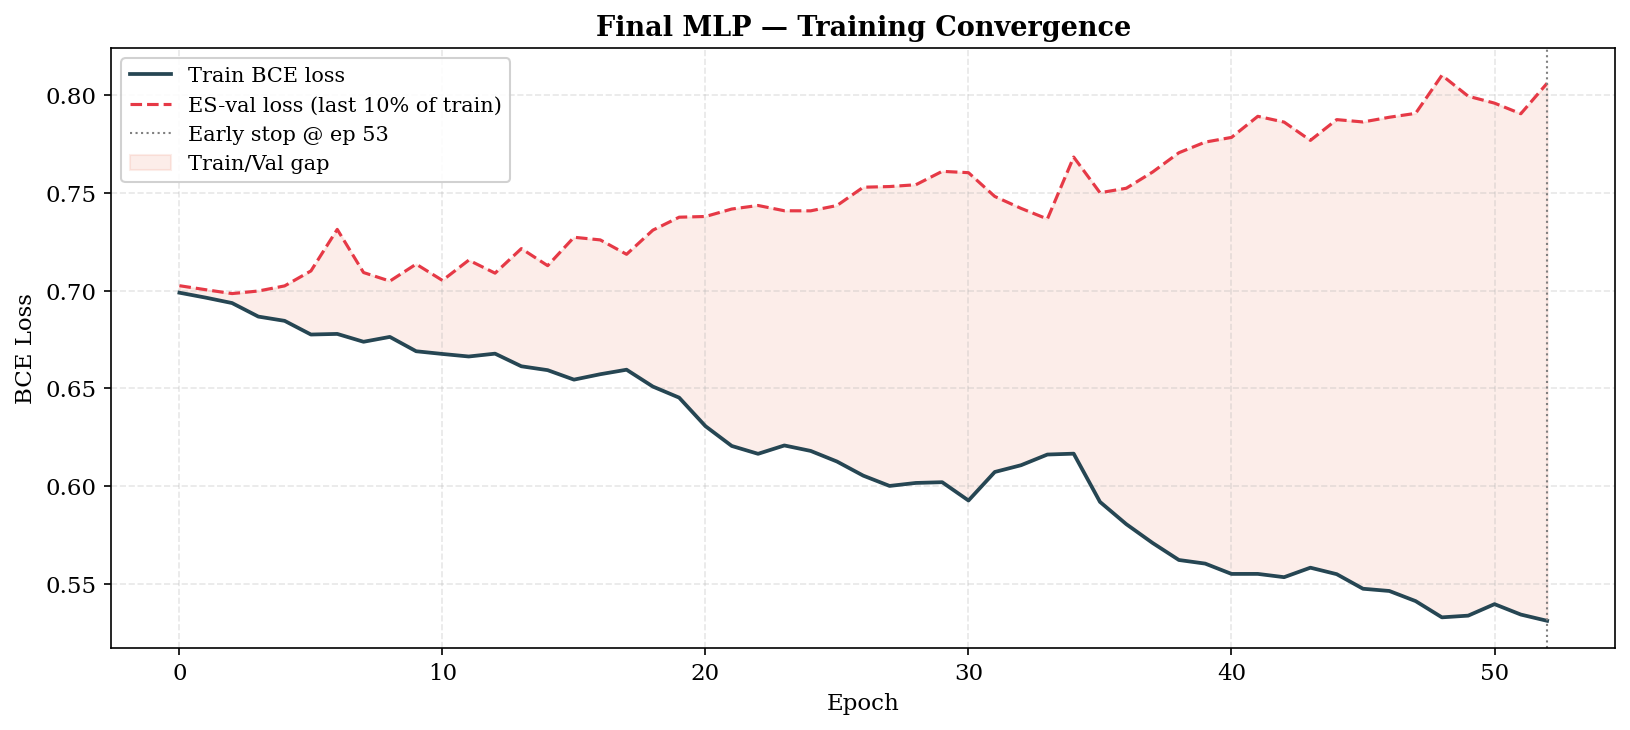

Early stop @ 53/500  final train=0.5313  val=0.8060


In [19]:
tr_l  = mlp_extractor.train_losses_
va_l  = mlp_extractor.val_losses_
n_ep  = len(tr_l)
n_com = min(len(tr_l), len(va_l))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(n_ep), tr_l, color=P['model'], lw=1.8, label='Train BCE loss')
ax.plot(range(len(va_l)), va_l, color=P['accent'], lw=1.5, ls='--',
        label='ES-val loss (last 10% of train)')
ax.axvline(n_ep-1, color='gray', lw=1, ls=':', label=f'Early stop @ ep {n_ep}')
ax.fill_between(range(n_com), tr_l[:n_com], va_l[:n_com],
                alpha=0.12, color=P['down'], label='Train/Val gap')
ax.set_title('Final MLP — Training Convergence', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(framealpha=0.9)
plt.tight_layout(); plt.show()
print(f'Early stop @ {n_ep}/{MLP_MAX_EPOCHS}  '
      f'final train={tr_l[-1]:.4f}  val={va_l[-1]:.4f}')

## 17. Standalone MLP Evaluation

In [20]:
print('=' * 60); print('  STANDALONE MLP'); print('=' * 60)
mlp_train_m = mlp_extractor.evaluate(X_train, y_train, label='Train (MLP)')
mlp_val_m   = mlp_extractor.evaluate(X_val,   y_val,   label='Validation (MLP)')
mlp_test_m  = mlp_extractor.evaluate(X_test,  y_test,  label='Test (MLP)')

  STANDALONE MLP

──────────────────────────────────────────────────
  Train (MLP)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.54      0.43      0.48      3947
     Up (+1)       0.53      0.64      0.58      4007

    accuracy                           0.54      7954
   macro avg       0.54      0.54      0.53      7954
weighted avg       0.54      0.54      0.53      7954

  ROC-AUC : 0.5581
  F1 (wtd): 0.5329

──────────────────────────────────────────────────
  Validation (MLP)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.49      0.43      0.46      1240
     Up (+1)       0.54      0.61      0.58      1395

    accuracy                           0.52      2635
   macro avg       0.52      0.52      0.52      2635
weighted avg       0.52      0.52      0.52      2635

  ROC-AUC : 0.5172
  F1 (wtd): 0.5199

─────────────

## 18. Train Elastic Net on MLP Embeddings

In [21]:
print(f'EN CV on {emb_dim}-dim embeddings (was 960 in baseline)')
t0 = time.time()
en_model = ElasticNetClassifier(
    Cs=np.logspace(-2,1,5), l1_ratios=[0.2,0.5,0.8], n_splits=5, max_iter=1000)
en_model.fit(E_train, y_train.values,
             feature_names=[f'emb_{i:02d}' for i in range(emb_dim)])
print(f'EN time: {time.time()-t0:.1f}s')

EN CV on 128-dim embeddings (was 960 in baseline)
  Config 1/15  C=0.0100  l1=0.2  .....  AUC=0.5672
  Config 2/15  C=0.0100  l1=0.5  .....  AUC=0.5607
  Config 3/15  C=0.0100  l1=0.8  .....  AUC=0.5396
  Config 4/15  C=0.0562  l1=0.2  .....  AUC=0.5651
  Config 5/15  C=0.0562  l1=0.5  .....  AUC=0.5652
  Config 6/15  C=0.0562  l1=0.8  .....  AUC=0.5650
  Config 7/15  C=0.3162  l1=0.2  .....  AUC=0.5631
  Config 8/15  C=0.3162  l1=0.5  .....  AUC=0.5638
  Config 9/15  C=0.3162  l1=0.8  .....  AUC=0.5638
  Config 10/15  C=1.7783  l1=0.2  .....  AUC=0.5624
  Config 11/15  C=1.7783  l1=0.5  .....  AUC=0.5625
  Config 12/15  C=1.7783  l1=0.8  .....  AUC=0.5626
  Config 13/15  C=10.0000  l1=0.2  .....  AUC=0.5623
  Config 14/15  C=10.0000  l1=0.5  .....  AUC=0.5623
  Config 15/15  C=10.0000  l1=0.8  .....  AUC=0.5623
Best: C=0.0100  l1=0.2  cv_AUC=0.5672
EN time: 50.8s


## 19. Evaluate MLP -> Elastic Net Pipeline

In [22]:
print('=' * 60); print('  MLP -> ELASTIC NET'); print('=' * 60)
pipe_train_m = en_model.evaluate(E_train, y_train.values, label='Train (MLP->EN)')
pipe_val_m   = en_model.evaluate(E_val,   y_val.values,   label='Validation (MLP->EN)')
pipe_test_m  = en_model.evaluate(E_test,  y_test.values,  label='Test (MLP->EN)')

print('\n' + '=' * 60); print('  NAIVE BASELINE'); print('=' * 60)
naive_val  = naive_baseline_metrics(y_train, y_val.values)
naive_test = naive_baseline_metrics(y_train, y_test.values)

  MLP -> ELASTIC NET

──────────────────────────────────────────────────
  Train (MLP->EN)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.58      0.53      0.55      3947
     Up (+1)       0.57      0.62      0.60      4007

    accuracy                           0.58      7954
   macro avg       0.58      0.57      0.57      7954
weighted avg       0.58      0.58      0.57      7954

  ROC-AUC : 0.6090
  F1 (wtd): 0.5742

──────────────────────────────────────────────────
  Validation (MLP->EN)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.49      0.50      0.49      1240
     Up (+1)       0.54      0.53      0.54      1395

    accuracy                           0.52      2635
   macro avg       0.52      0.52      0.52      2635
weighted avg       0.52      0.52      0.52      2635

  ROC-AUC : 0.5163
  F1 (wtd): 0.5171

─

## 20. Comparison Against Baseline Elastic Net

Baseline EN (raw 960-dim features): **Train AUC ~0.67 | Val AUC ~0.4933 | Test AUC ~0.5156**

In [23]:
BASELINE_PKL = Path('elasticnet_wti_direction.pkl')

if BASELINE_PKL.exists():
    print(f'Loading baseline from {BASELINE_PKL}...')
    baseline_en = ElasticNetClassifier(); baseline_en.load(str(BASELINE_PKL))
    b_train = evaluate_classification(y_train.values, baseline_en.predict(X_train),
                  baseline_en.predict_proba(X_train), label='Baseline EN Train')
    b_val   = evaluate_classification(y_val.values,   baseline_en.predict(X_val),
                  baseline_en.predict_proba(X_val),   label='Baseline EN Val')
    b_test  = evaluate_classification(y_test.values,  baseline_en.predict(X_test),
                  baseline_en.predict_proba(X_test),  label='Baseline EN Test')
else:
    print('[INFO] baseline pkl not found — using recorded numbers.')
    b_train = {'roc_auc': 0.67,   'accuracy': None, 'f1_weighted': None}
    b_val   = {'roc_auc': 0.4933, 'accuracy': 0.4972, 'f1_weighted': 0.4972}
    b_test  = {'roc_auc': 0.5156, 'accuracy': 0.4907, 'f1_weighted': 0.4899}

Loading baseline from elasticnet_wti_direction.pkl...

──────────────────────────────────────────────────
  Baseline EN Train
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.62      0.60      0.61      3947
     Up (+1)       0.61      0.63      0.62      4007

    accuracy                           0.61      7954
   macro avg       0.61      0.61      0.61      7954
weighted avg       0.61      0.61      0.61      7954

  ROC-AUC : 0.6584
  F1 (wtd): 0.6148

──────────────────────────────────────────────────
  Baseline EN Val
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.46      0.45      0.46      1240
     Up (+1)       0.52      0.53      0.53      1395

    accuracy                           0.49      2635
   macro avg       0.49      0.49      0.49      2635
weighted avg       0.49      0.49      0.49      2635

  ROC-AUC 

## 21. Full Summary Table

In [24]:
def fmt(v):
    return f'{v:.4f}' if (v is not None and not np.isnan(float(v if v is not None else np.nan))) else 'N/A'

rows = []
for split, naive_m, base_m, mlp_m, pipe_m in [
    ('Validation', naive_val,  b_val,   mlp_val_m,  pipe_val_m),
    ('Test',       naive_test, b_test,  mlp_test_m, pipe_test_m),
]:
    for name, m in [('Naive',naive_m),('Baseline EN',base_m),
                    ('MLP only',mlp_m),('MLP->EN',pipe_m)]:
        rows.append({'Split':split,'Model':name,
                     'Accuracy':fmt(m.get('accuracy')),
                     'F1 (wtd)':fmt(m.get('f1_weighted')),
                     'ROC-AUC': fmt(m.get('roc_auc'))})
print(pd.DataFrame(rows).to_string(index=False))

print('\n-- AUC delta vs Baseline EN --')
for split, bm, pm in [('Validation',b_val,pipe_val_m),('Test',b_test,pipe_test_m)]:
    d = pm['roc_auc'] - bm['roc_auc']
    print(f'  {split}: {bm["roc_auc"]:.4f} -> {pm["roc_auc"]:.4f}  '
          f'(delta={d:+.4f}  {"IMPROVEMENT" if d>0 else "degradation"})')

     Split       Model Accuracy F1 (wtd) ROC-AUC
Validation       Naive   0.5294   0.3665     N/A
Validation Baseline EN   0.4949   0.4945  0.4921
Validation    MLP only   0.5237   0.5199  0.5172
Validation     MLP->EN   0.5169   0.5171  0.5163
      Test       Naive   0.4954   0.3282     N/A
      Test Baseline EN   0.5000   0.4997  0.4987
      Test    MLP only   0.4861   0.4132  0.5096
      Test     MLP->EN   0.5278   0.5214  0.5306

-- AUC delta vs Baseline EN --
  Validation: 0.4921 -> 0.5163  (delta=+0.0242  IMPROVEMENT)
  Test: 0.4987 -> 0.5306  (delta=+0.0319  IMPROVEMENT)


---
# Visualizations

## 22. AUC Bar Chart

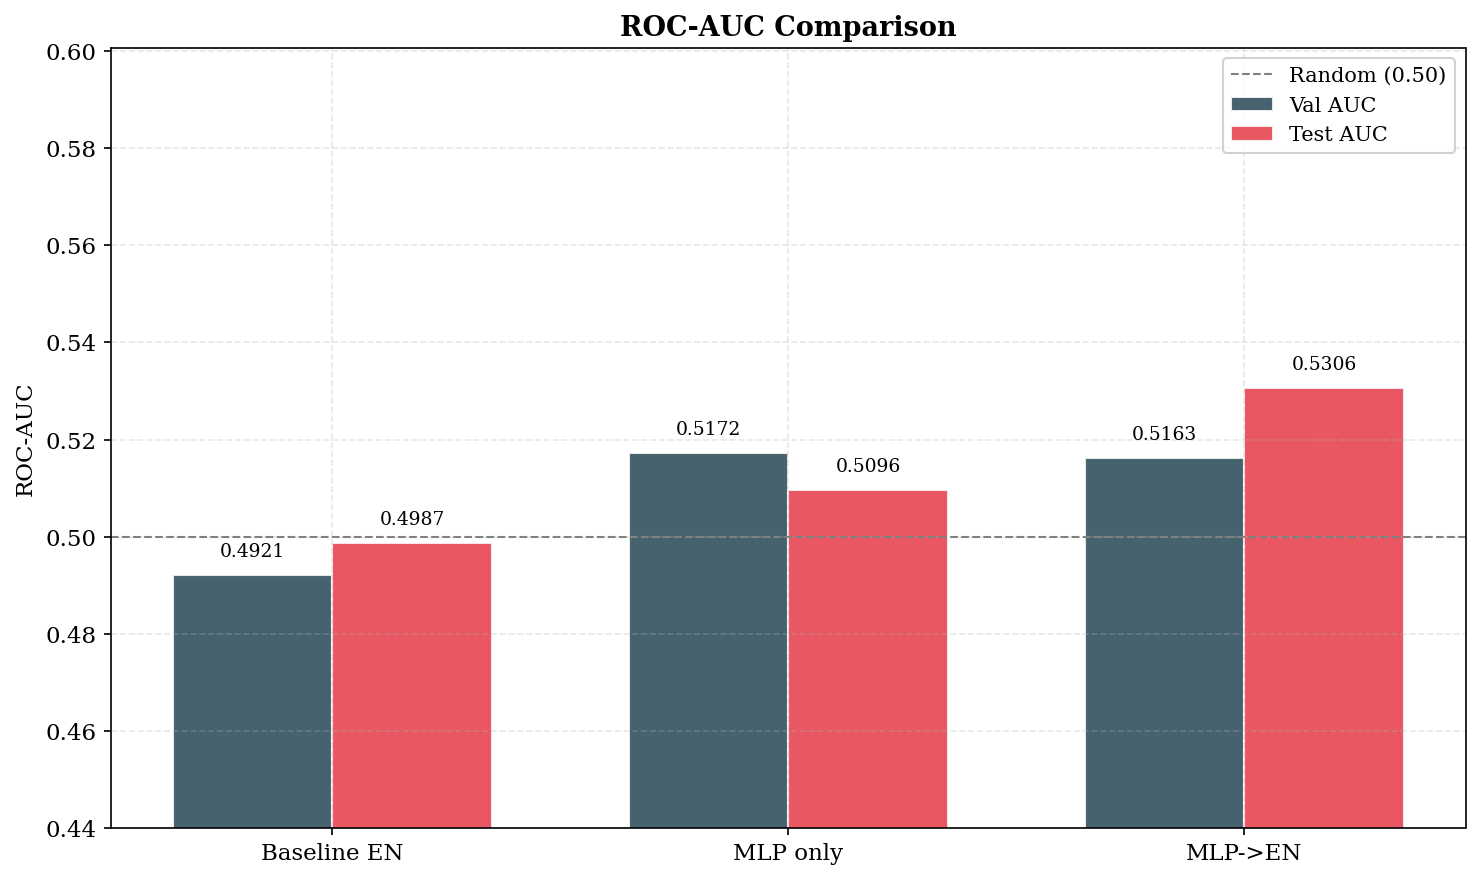

In [25]:
model_names   = ['Baseline EN','MLP only','MLP->EN']
val_aucs_b    = [b_val['roc_auc'],  mlp_val_m['roc_auc'],  pipe_val_m['roc_auc']]
test_aucs_b   = [b_test['roc_auc'], mlp_test_m['roc_auc'], pipe_test_m['roc_auc']]
x, w = np.arange(len(model_names)), 0.35
fig, ax = plt.subplots(figsize=(10,6))
b1 = ax.bar(x-w/2, val_aucs_b,  w, label='Val AUC',  color=P['model'],  alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, test_aucs_b, w, label='Test AUC', color=P['accent'], alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='gray', lw=1, ls='--', label='Random (0.50)')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.44, max(max(val_aucs_b),max(test_aucs_b))+0.07)
ax.set_title('ROC-AUC Comparison', fontweight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout(); plt.show()

## 23. ROC Curves

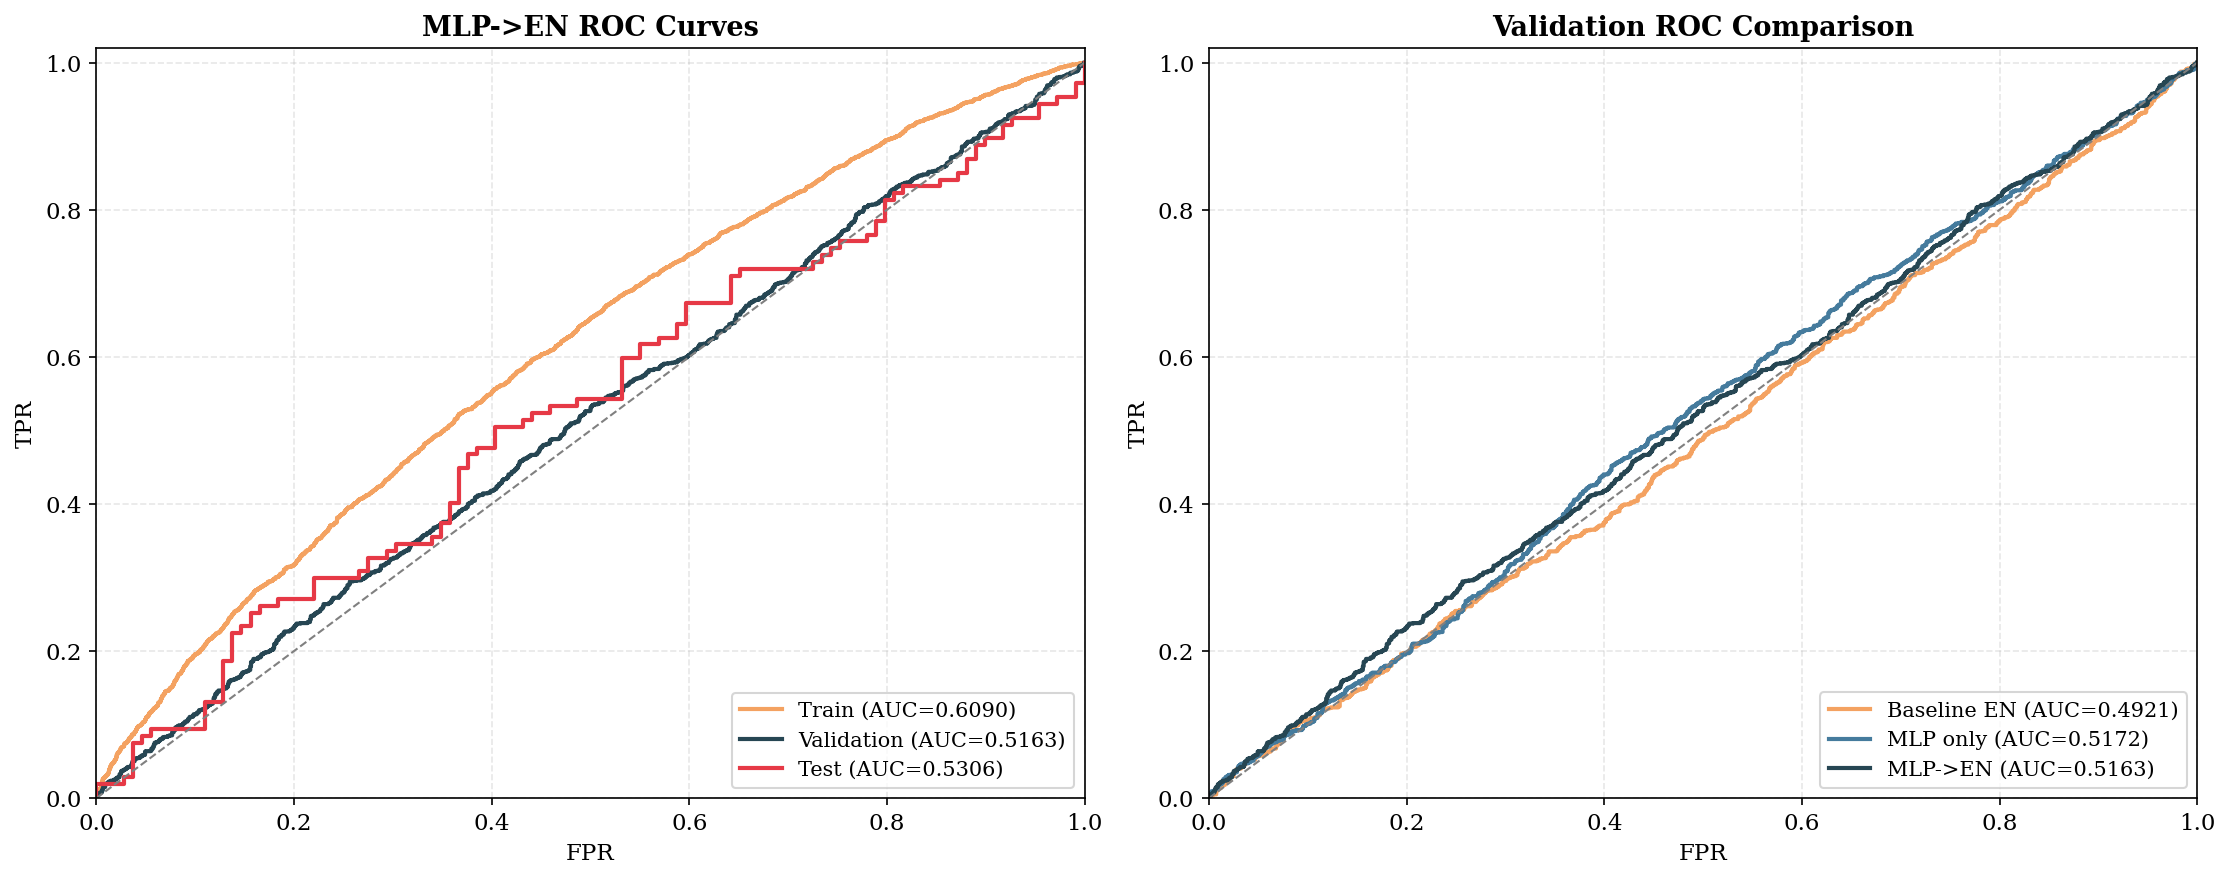

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
for lbl, yt, yp, col in [
    ('Train',      y_train.values, en_model.predict_proba(E_train), '#f4a261'),
    ('Validation', y_val.values,   en_model.predict_proba(E_val),   P['model']),
    ('Test',       y_test.values,  en_model.predict_proba(E_test),  P['accent']),
]:
    fpr, tpr, _ = roc_curve(yt, yp, pos_label=1)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{lbl} (AUC={roc_auc_score(yt,yp):.4f})')
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
ax.set_title('MLP->EN ROC Curves', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02]); ax.legend(loc='lower right')

ax = axes[1]
cmp = [('MLP only', y_val.values, mlp_extractor.predict_proba(X_val), P['mlp']),
       ('MLP->EN',  y_val.values, en_model.predict_proba(E_val),      P['model'])]
if BASELINE_PKL.exists():
    cmp.insert(0, ('Baseline EN', y_val.values, baseline_en.predict_proba(X_val), '#f4a261'))
for lbl, yt, yp, col in cmp:
    fpr, tpr, _ = roc_curve(yt, yp, pos_label=1)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{lbl} (AUC={roc_auc_score(yt,yp):.4f})')
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
if not BASELINE_PKL.exists():
    ax.annotate(f'Baseline EN val AUC~{b_val["roc_auc"]:.4f}',
                xy=(0.5,0.35), xycoords='axes fraction', ha='center',
                fontsize=9, color='#f4a261',
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_title('Validation ROC Comparison', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02]); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 24. Confusion Matrices

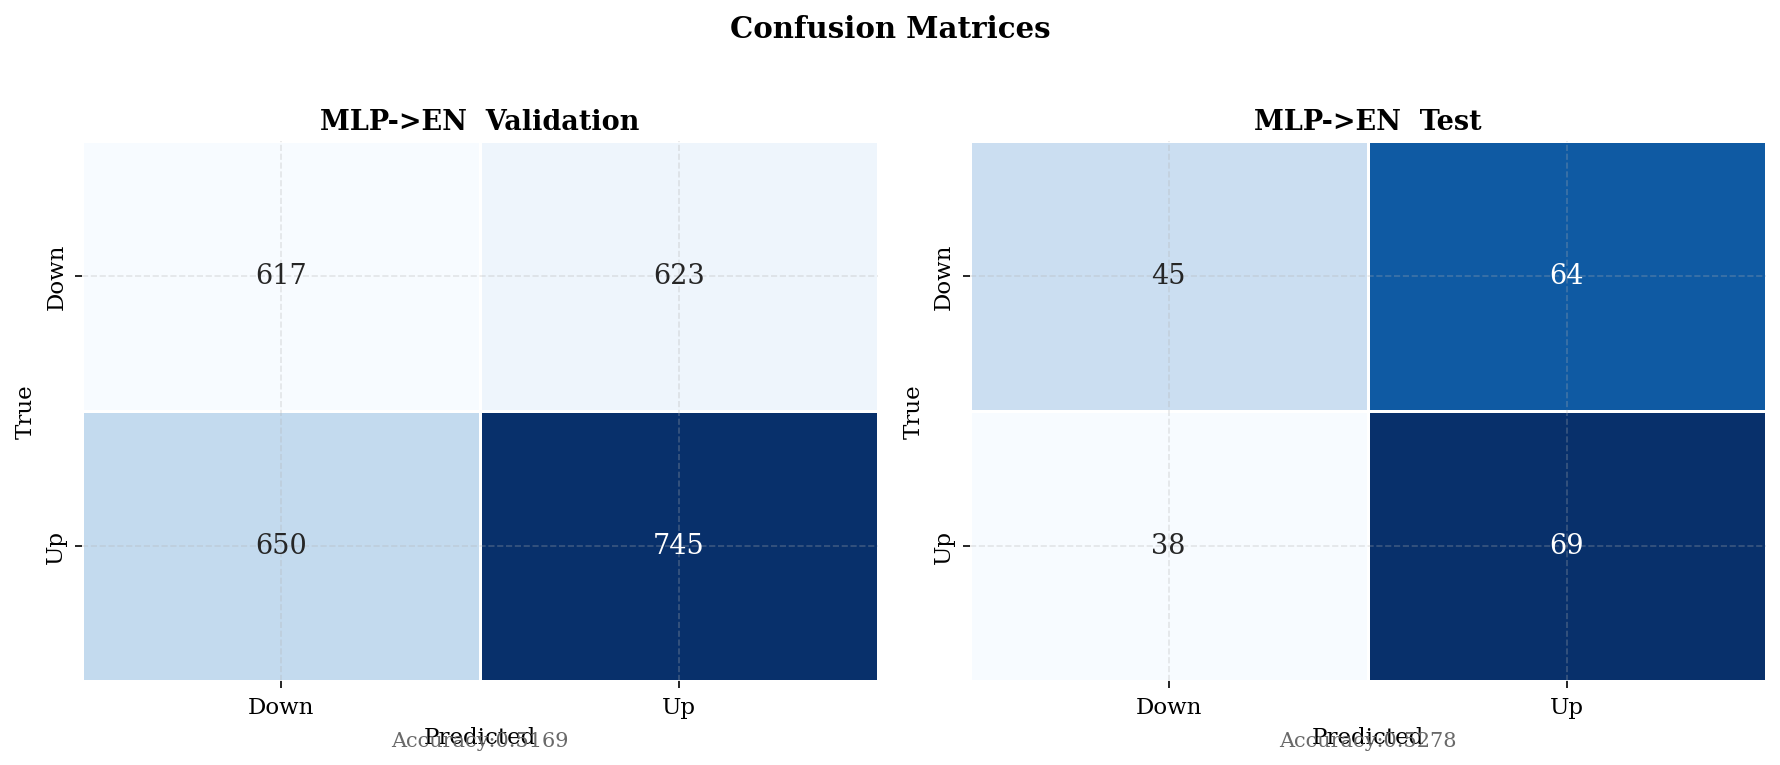

In [27]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax, E, yt, title in [(axes[0],E_val,y_val.values,'Validation'),
                          (axes[1],E_test,y_test.values,'Test')]:
    yp = en_model.predict(E)
    sns.heatmap(confusion_matrix(yt,yp,labels=[-1,1]),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down','Up'], yticklabels=['Down','Up'],
                linewidths=0.5, ax=ax, cbar=False, annot_kws={'size':13})
    ax.set_title(f'MLP->EN  {title}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.text(0.5,-0.12,f'Accuracy:{accuracy_score(yt,yp):.4f}',
            transform=ax.transAxes, ha='center', fontsize=10, color='dimgray')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 25. EN CV AUC vs Regularisation

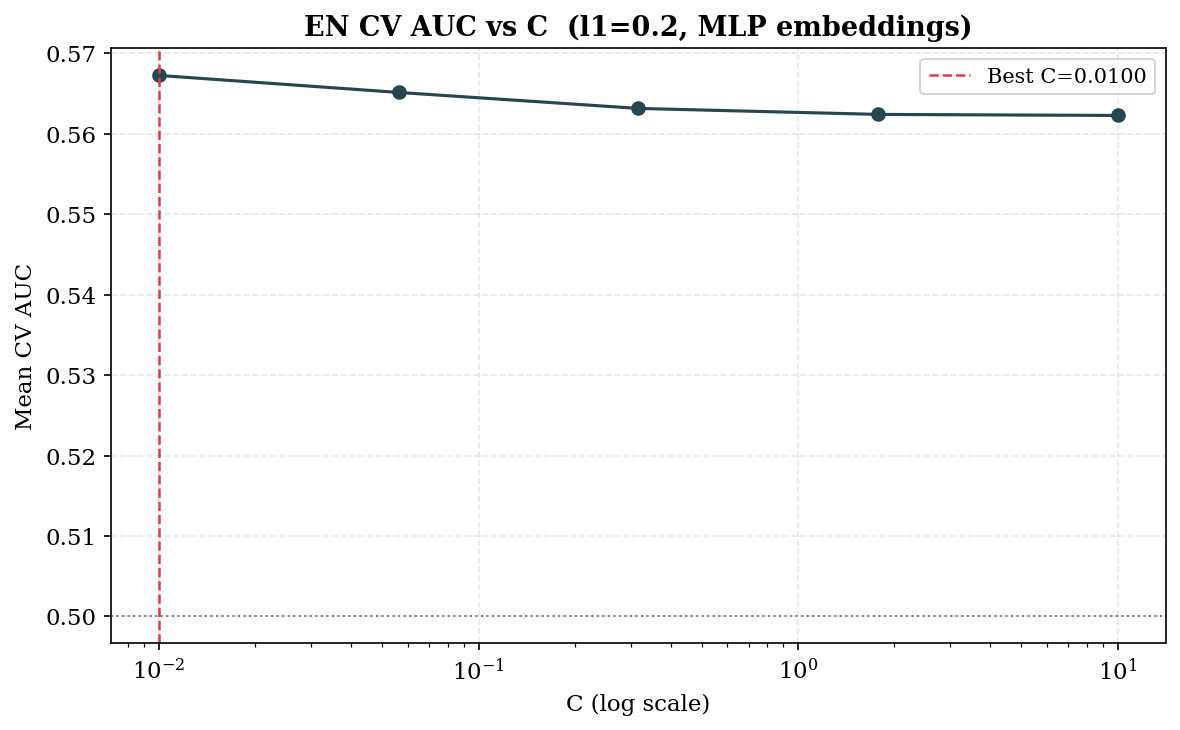

In [28]:
cv_df   = pd.DataFrame(en_model.cv_results_)
best_l1 = en_model.best_params_['l1_ratio']
dp = cv_df[cv_df['l1_ratio']==best_l1].sort_values('C')
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(dp['C'], dp['roc_auc'], marker='o', color=P['model'], lw=1.5, ms=6)
ax.axvline(en_model.best_params_['C'], color=P['accent'], ls='--', lw=1.2,
           label=f"Best C={en_model.best_params_['C']:.4f}")
ax.axhline(0.5, color='gray', lw=1, ls=':')
ax.set_xscale('log')
ax.set_title(f'EN CV AUC vs C  (l1={best_l1}, MLP embeddings)', fontweight='bold')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Mean CV AUC')
ax.legend(); plt.tight_layout(); plt.show()

## 26. EN Coefficients on Embeddings

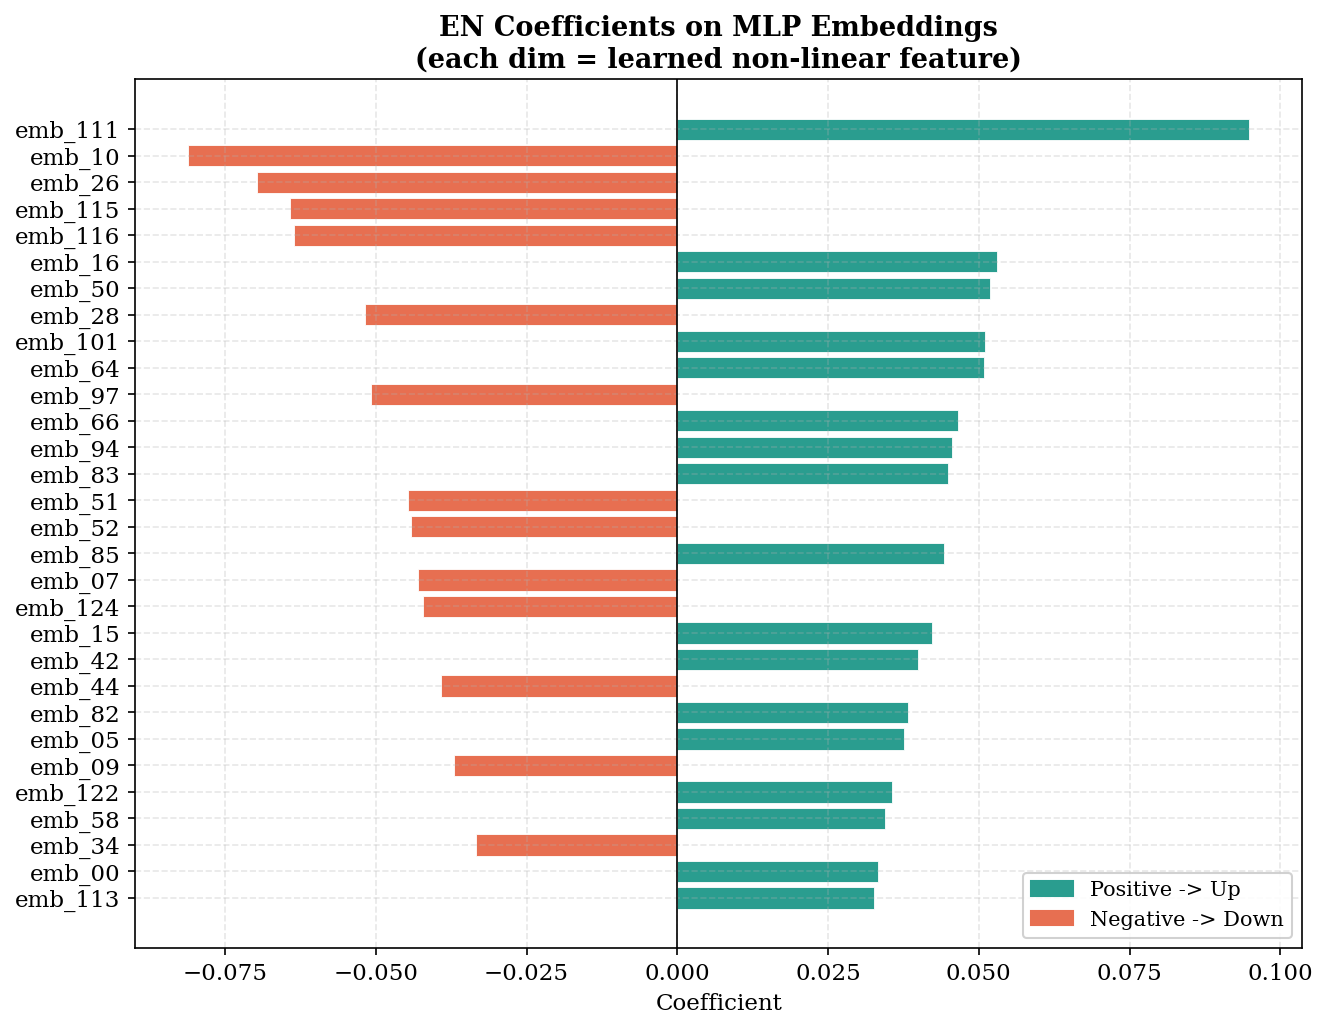

feature      coef
emb_111  0.094862
 emb_10 -0.081148
 emb_26 -0.069673
emb_115 -0.064174
emb_116 -0.063573
 emb_16  0.052949
 emb_50  0.051827
 emb_28 -0.051782
emb_101  0.051083
 emb_64  0.050885
 emb_97 -0.050724
 emb_66  0.046607
 emb_94  0.045496
 emb_83  0.044816
 emb_51 -0.044602
 emb_52 -0.044223
 emb_85  0.044154
 emb_07 -0.043018
emb_124 -0.042208
 emb_15  0.042153
 emb_42  0.039840
 emb_44 -0.039180
 emb_82  0.038302
 emb_05  0.037565
 emb_09 -0.037041
emb_122  0.035663
 emb_58  0.034487
 emb_34 -0.033315
 emb_00  0.033281
emb_113  0.032679


In [29]:
coef_df = en_model.coef_table(top_n=min(30,emb_dim))
fig, ax = plt.subplots(figsize=(9,7))
colors  = [P['up'] if v>0 else P['down'] for v in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('EN Coefficients on MLP Embeddings\n(each dim = learned non-linear feature)', fontweight='bold')
ax.set_xlabel('Coefficient')
ax.legend(handles=[mpatches.Patch(color=P['up'],label='Positive -> Up'),
                   mpatches.Patch(color=P['down'],label='Negative -> Down')],
          loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()
print(coef_df.to_string(index=False))

## 27. Rolling Accuracy — Test Set

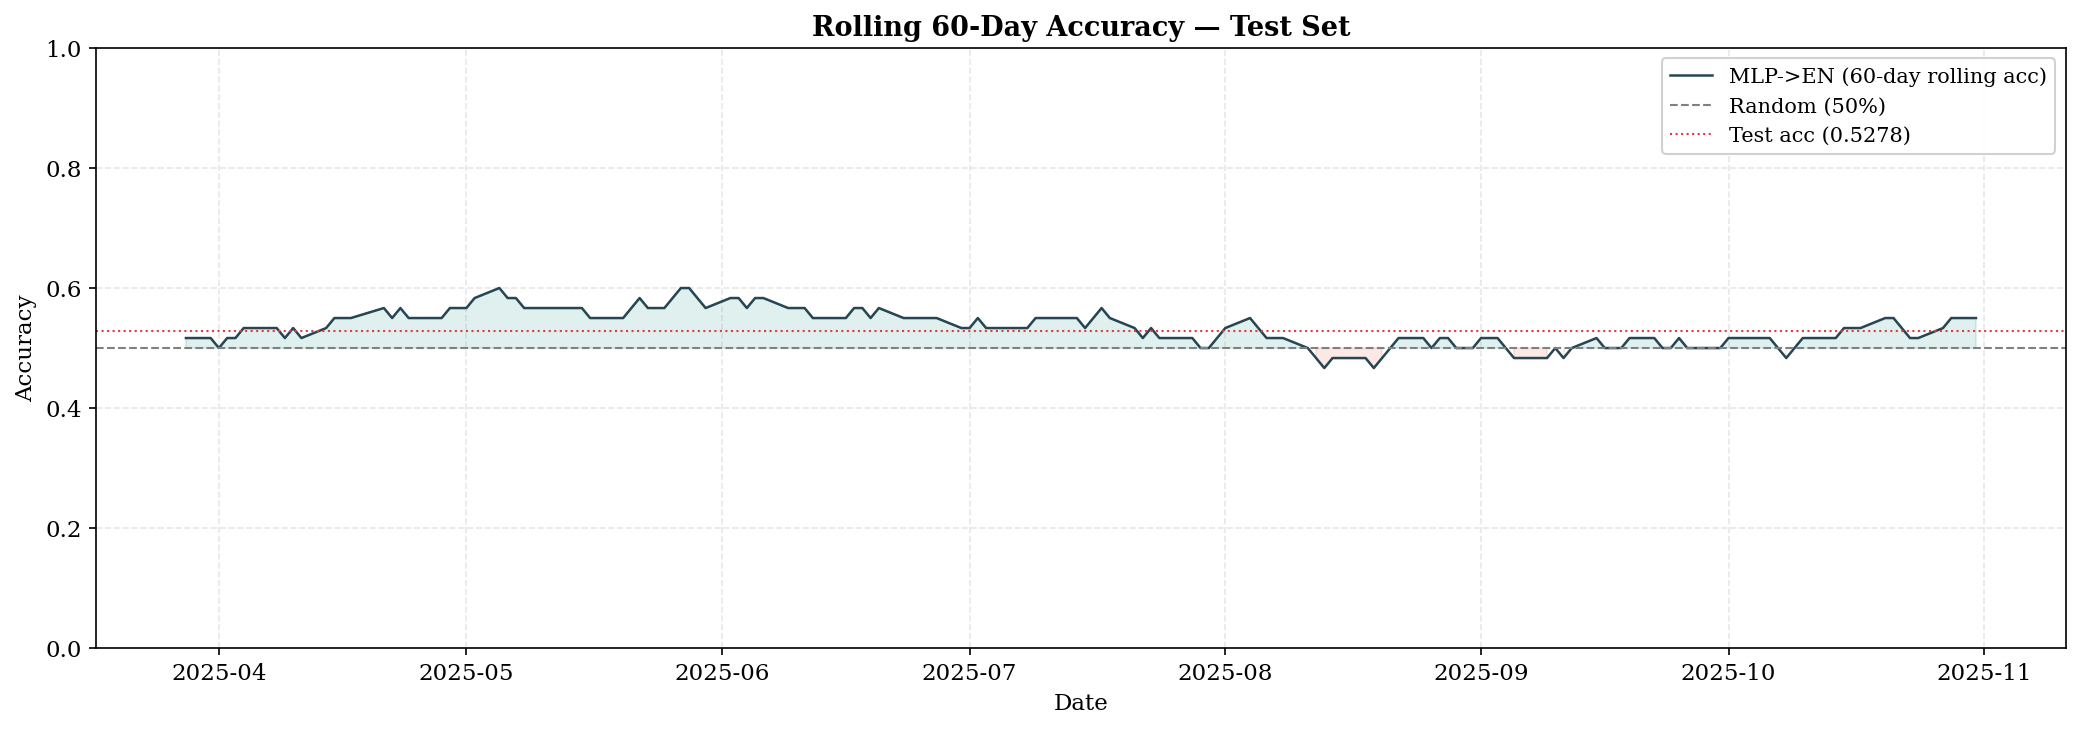

In [30]:
roll_w   = 60
pred_t   = en_model.predict(E_test)
roll_acc = pd.Series((pred_t==y_test.values).astype(int),
                     index=y_test.index).rolling(roll_w).mean()
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(roll_acc.index, roll_acc.values, color=P['model'], lw=1.2,
        label=f'MLP->EN ({roll_w}-day rolling acc)')
ax.axhline(0.5, color='gray', lw=1, ls='--', label='Random (50%)')
ax.axhline(pipe_test_m['accuracy'], color=P['accent'], lw=1, ls=':',
           label=f"Test acc ({pipe_test_m['accuracy']:.4f})")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values>=0.5, alpha=0.15, color=P['up'])
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values<0.5,  alpha=0.15, color=P['down'])
ax.set_title(f'Rolling {roll_w}-Day Accuracy — Test Set', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_xlabel('Date'); ax.set_ylim(0,1)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

## 28. Save Models

In [31]:
mlp_extractor.save('mlp_extractor_wti.pkl')
en_model.save('mlp_en_wti_direction.pkl')
print('Saved: mlp_extractor_wti.pkl  |  mlp_en_wti_direction.pkl')
# Reload: mlp.load(...); en.load(...); preds = en.predict(mlp.get_embeddings(X_new))

Saved: mlp_extractor_wti.pkl  |  mlp_en_wti_direction.pkl
